Name: Manan Bhatia

Student ID: 22035587

**About CIFAR:** 

The CIFAR-10 dataset is a collection of images that are commonly used to train machine learning and computer vision algorithms. It is one of the most widely used datasets for machine learning research. The CIFAR-10 dataset contains 60,000 32x32 color images in 10 different classes. The 10 different classes represent airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks. There are 6,000 images of each class. See https://www.cs.toronto.edu/~kriz/cifar.html for details

# Task

Need to accomplish the following tasks for this assignment
1. Randomly select 3 classes with 100 images per class for this assignment
2. Build the autoencoder model using CNN with functioning training code (if not CNN based, 60% reduction of marks will incur for this task)
3. Plot the learnt images 2D coordinates (normally called *embeddings* in machine learning) of all images in training with each class denoted b a symbol, for example, circles for dogs, triangles for cats and so on
4. Randomly select 5 images that are not in the training set and obtain their 2D representations, add them to the plot produced in task 3 and describe what do you think about them in terms of their locations in relations to others.

Open the CIFAR - 10 Dataset

In [13]:
import numpy as np
import os
import random
import matplotlib.pyplot as plt

#random split modules
from torch.utils.data import random_split

#to load and normalise CIFAR10
import torch
from torch.utils.data import DataLoader
from torch import nn
from torch.nn import ConvTranspose2d

import torchvision
from torchvision import transforms 
from torchviz import make_dot
from torchvision.datasets import CIFAR10
from torchviz import make_dot
import hiddenlayer as hl

In [15]:
from torchvision.datasets import CIFAR10
from torchvision import transforms
import os

CIF_dataset = CIFAR10(root=os.getcwd(), transform=transforms.ToTensor(), download=True)


Files already downloaded and verified


In [17]:
format(CIF_dataset.classes)

"['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']"

In [19]:
random.seed(1)
random.sample(range(0,9), 3)
#this return 2, 1, 8 which stand for bird, automobile and ship

[2, 1, 8]

In [21]:
r1 = list(np.where(np.array(CIF_dataset.targets) == 5)[0])[0:100]
r2 = list(np.where(np.array(CIF_dataset.targets) == 3)[0])[0:100]
r3 = list(np.where(np.array(CIF_dataset.targets) == 7)[0])[0:100]
r_total = r1 + r2 + r3

In [23]:
dataset_CIF = torch.utils.data.Subset(CIF_dataset, r_total)
len(dataset_CIF) #300 images with 100 per class (3 classes total)

300

In [25]:
train_data, val_data, test_data = torch.utils.data.random_split(dataset_CIF, [50, 50, 200])

In [27]:
train_loadpck = torch.utils.data.DataLoader(train_data, batch_size = 64, shuffle = True)
val_loadpck = torch.utils.data.DataLoader(val_data, batch_size = 64, shuffle = True)

In [29]:
#define my own CNN architecture 
class mySmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layer = nn.Sequential(
            #Conv block
            nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = 3, padding = 1),
            nn.ReLU(inplace = True),
            nn.Conv2d(in_channels = 32, out_channels = 16, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace = True),
            nn.MaxPool2d(kernel_size = 2, stride = 2)
        )
        self.fc_layer = nn.Sequential(
            nn.Dropout(p = 0.1),
            nn.Linear(in_features = 4096, out_features = 128),
            nn.ReLU(inplace = True),
            nn.Dropout(p = 0.1),
            nn.Linear(in_features = 128, out_features =  10),
            nn.Softmax(dim = 1)
        )
        
    def forward(self, x):
        x = self.conv_layer(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layer(x)
        return x

model = mySmallCNN()

In [31]:
def train_model(optimiser, model, loss_function, trainloader, valloader, 
                n_epochs=10, fplotloss=True, fdraw=False, mode=1):
    # move tensors to GPU if CUDA is available
    train_on_gpu = torch.cuda.is_available()
    if train_on_gpu:
        print("GPU is available! Train model on GPU.")
        model.cuda()
    
    train_losslist = []
    val_losslist = []
   
    
    # Track the best model so far (evaluated on validation set)
    val_loss_min = np.Inf 
    
    print("Entering training cycles.")
    for epoch in [*range(n_epochs)]:
    
        # keep track of training and validation loss
        train_loss = 0.0
        val_loss = 0.0
        
        # train the model, one training cycle
        model.train()
        for data, target in trainloader:
            # move tensors to GPU if CUDA is available
            if train_on_gpu:
                data, target = data.cuda(), target.cuda()
            # clear the gradients of all optimized variables
            optimiser.zero_grad()
            # forward pass: compute predicted outputs by passing inputs to the model
            output = model(data)
            # calculate the batch loss
            if mode==0:
                loss = loss_function(output, target)
            else: # Be careful with the AE mode training
                loss = loss_function(output[0], data)
            # backward pass: compute gradient of the loss with respect to model parameters
            loss.backward()
            # perform a single optimization step (parameter update)
            optimiser.step()
            # update training loss
            train_loss += loss.item() * data.size(0)
 
        # validate the model 
        model.eval()
        for data, target in valloader:
            # move tensors to GPU if CUDA is available
            if train_on_gpu:
                data, target = data.cuda(), target.cuda()
            # forward pass: compute predicted outputs by passing inputs to the model
            output = model(data)
            # calculate the batch loss
            if mode==0:
                loss = loss_function(output, target)
            else: 
                loss = loss_function(output[0], data)
            # update average validation loss 
            val_loss += loss.item() * data.size(0)
        
        # calculate average losses
        train_loss = train_loss / len(trainloader.dataset)
        val_loss = val_loss / len(valloader.dataset)
    
        train_losslist.append(train_loss)
        val_losslist.append(val_loss)
            
        # print training/validation statistics 
        print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
            epoch, train_loss, val_loss))
        
        # save model if validation loss has decreased
        if val_loss <= val_loss_min:
            print('Validation loss decreased ({:.6f} --> {:.6f})')
            val_loss_min = val_loss

    
    # Plot training and validation loss if fplotloss=True
    if fplotloss:
        plt.plot(*range(n_epochs), train_losslist)
        plt.plot(*range(n_epochs), val_losslist)
        plt.ylim((min(train_losslist+val_losslist),max(train_losslist+val_losslist)))
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Performance of the model")
        plt.legend(["Training loss","Validation loss"])
        plt.show()    

    # Process is complete.
    print('Training process has finished.')
    return train_losslist, val_losslist

In [33]:
def calculate_accuracy(y_pred, y): # Get accuracy manually
# y_pred: the output from the model
# y: the true labels
    top_pred = y_pred.argmax(1, keepdim=True)
    correct = top_pred.eq(y.view_as(top_pred)).sum()
    acc = correct.float() / y.shape[0]
    return acc,top_pred   

Entering training cycles.
Epoch: 0 	Training Loss: 2.309282 	Validation Loss: 2.305165
Validation loss decreased ({:.6f} --> {:.6f})
Epoch: 1 	Training Loss: 2.305284 	Validation Loss: 2.304640
Validation loss decreased ({:.6f} --> {:.6f})
Epoch: 2 	Training Loss: 2.297443 	Validation Loss: 2.304067
Validation loss decreased ({:.6f} --> {:.6f})
Epoch: 3 	Training Loss: 2.294547 	Validation Loss: 2.303468
Validation loss decreased ({:.6f} --> {:.6f})
Epoch: 4 	Training Loss: 2.286635 	Validation Loss: 2.302803
Validation loss decreased ({:.6f} --> {:.6f})
Epoch: 5 	Training Loss: 2.281375 	Validation Loss: 2.302098
Validation loss decreased ({:.6f} --> {:.6f})
Epoch: 6 	Training Loss: 2.276880 	Validation Loss: 2.301288
Validation loss decreased ({:.6f} --> {:.6f})
Epoch: 7 	Training Loss: 2.269165 	Validation Loss: 2.300440
Validation loss decreased ({:.6f} --> {:.6f})
Epoch: 8 	Training Loss: 2.258765 	Validation Loss: 2.299407
Validation loss decreased ({:.6f} --> {:.6f})
Epoch: 9 	T

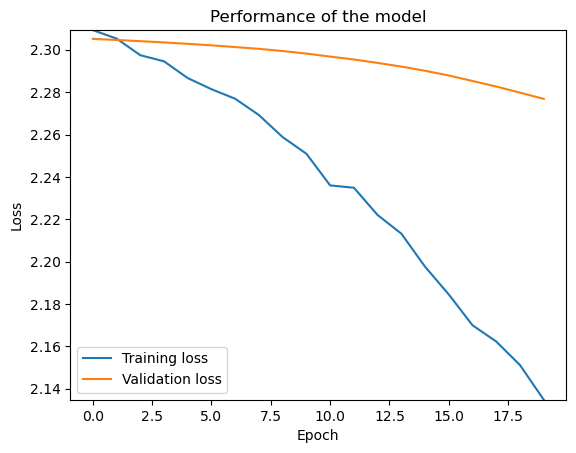

Training process has finished.


In [35]:
if __name__ == '__main__':
    torch.manual_seed(42)
    #use cifar
    optimiser = torch.optim.SGD(model.parameters(), lr = .01)
    #use CrossEntropyLoss
    train_model(optimiser, model, nn.CrossEntropyLoss(),train_loadpck,val_loadpck,
                n_epochs = 20, fplotloss = True, fdraw = True, mode = 0);

In [37]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [39]:
#Building the model again:
#define my own CNN architecture 
class mySmallCNN_AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
                             #Conv block
                             nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 3, padding = 2), #layer 1

                             #hidden 2
                             nn.ReLU(inplace = True),
                             nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 2, padding = 1),
                            
                             #hidden 3
                             nn.BatchNorm2d(32),
                             nn.ReLU(inplace = True),
                             nn.MaxPool2d(kernel_size = 4, stride = 2))
        
        self.decoder = nn.Sequential(
                            nn.Dropout(p = 0.1),
                            nn.ConvTranspose2d(32, 16, kernel_size = 2),
                            nn.ReLU(inplace = True),
                            nn.Dropout(p = 0.1),
                            nn.ConvTranspose2d(16, 3, kernel_size = 3),
                            nn.Softmax(dim = 1))
        
    def forward(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x

In [41]:
print('My model: ')
print(mySmallCNN_AE())

My model: 
mySmallCNN_AE(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): Conv2d(16, 32, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=4, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): Dropout(p=0.1, inplace=False)
    (1): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(1, 1))
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): ConvTranspose2d(16, 3, kernel_size=(3, 3), stride=(1, 1))
    (5): Softmax(dim=1)
  )
)


In [43]:
transform = transforms.ToTensor()

In [45]:
dataiter = iter(train_loadpck)
images, labels = next(dataiter)
print(torch.min(images), torch.max(images))

tensor(0.) tensor(1.)


In [64]:
class CNNAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),  # [N, 16, 16, 16]
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # [N, 32, 8, 8]
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # [N, 64, 4, 4]
            nn.ReLU(),
            nn.Flatten(),                                          # [N, 64 * 4 * 4]
            nn.Linear(64 * 4 * 4, 128)                             # [N, 128] - Embedding layer
        )
        self.decoder = nn.Sequential(
            nn.Linear(128, 64 * 4 * 4),                           # [N, 64 * 4 * 4]
            nn.ReLU(),
            nn.Unflatten(1, (64, 4, 4)),                         # [N, 64, 4, 4]
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # [N, 32, 8, 8]
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # [N, 16, 16, 16]
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # [N, 3, 32, 32]
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded_val = self.encoder(x)
        decoded_val = self.decoder(encoded_val)
        return decoded_val

In [66]:
model = CNNAutoEncoder()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

In [68]:
num_epochs = 10
outputs = []
for epoch in range(num_epochs):
    for (img, _) in train_loadpck:
        recon = model(img)
        loss = criterion(recon, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f'Epoch: {epoch + 1}, loss: {loss.item():.4f}')
    outputs.append((epoch,img, recon))

Epoch: 1, loss: 1.4722
Epoch: 2, loss: 1.4721
Epoch: 3, loss: 1.4720
Epoch: 4, loss: 1.4719
Epoch: 5, loss: 1.4718
Epoch: 6, loss: 1.4717
Epoch: 7, loss: 1.4715
Epoch: 8, loss: 1.4713
Epoch: 9, loss: 1.4709
Epoch: 10, loss: 1.4705


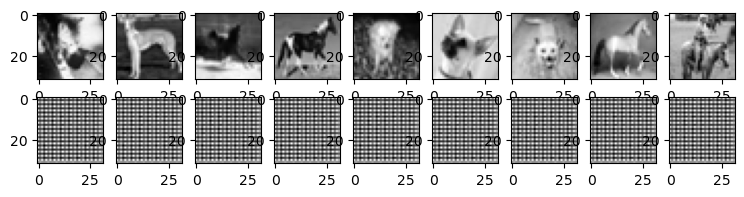

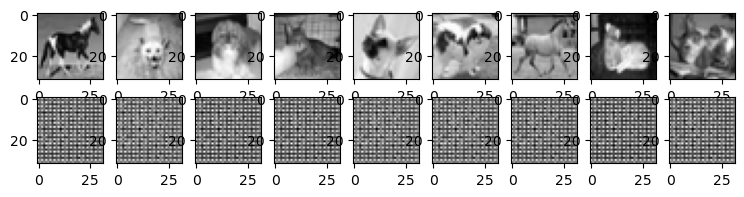

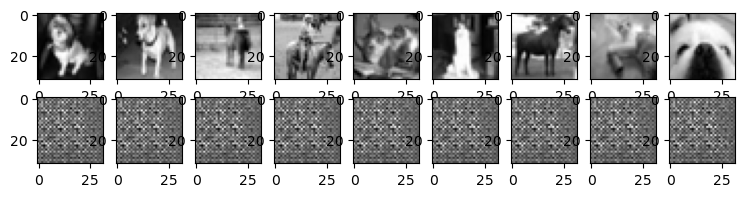

In [72]:
for k in range(0, num_epochs, 4):
    plt.figure(figsize = (9, 2))
    plt.gray()
    imgs = outputs[k][1].detach().numpy()
    recon = outputs[k][2].detach().numpy()
    for i, item in enumerate(imgs):
        if i >= 9:
            break
        plt.subplot(2,9, i+1)
        item = item.reshape(-3, 32, 32)
        plt.imshow(item[0])
        
    for i, item in enumerate(recon):
        if i >= 9: break
        plt.subplot(2, 9 , 9+i+1) #row_length + i + 1
        item = item.reshape(-3, 32, 32)
        #item: 1, 28, 28
        plt.imshow(item[0])